# Télécharge votre tranche des comptages routiers permanents de la Ville de Paris.




1. Remplacez ROUTES par vos 3 axes (noms exacts de la colonne `axe` de liste_des_axes.csv).
2. Lancez : python download_data.py
3. Les données arrivent dans data/raw/comptages.csv (dossier ignoré par Git).

Source : https://opendata.paris.fr/explore/dataset/comptages-routiers-permanents/



## Import, Traitement et Analyse des données

In [15]:
from pathlib import Path
import requests
import pandas as pd
import os
from datetime import datetime as dt
from jupyter_toc import toc

ImportError: cannot import name 'display' from 'IPython.core.display' (d:\Master\DM2\Analyse_de_donnees\Aivanvity-projet-trafic\.venv\Lib\site-packages\IPython\core\display.py)

In [2]:
ROUTES = ["Lecourbe", "Av_Foch", "Av_Daumesnil"]  # ex. ["Pyrenees", "Av_de_Clichy", "Voie_Mazas"]
DATE_DEBUT = "2026-03-01"
DATE_FIN = "2026-09-01"  # exclue

In [3]:
URL = ("https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/"
       "comptages-routiers-permanents/exports/csv")
COLONNES = ("iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,"
            "iu_nd_aval,libelle_nd_aval,etat_barre")
SORTIE = Path(os.getcwd()) / "data" / "comptages_trafic.csv"

CHEMIN = SORTIE


In [4]:
def main():
    if len(ROUTES) != 3:
        raise SystemExit("Renseignez vos 3 axes dans ROUTES avant de lancer le script.")
    axes = ",".join(f"'{r}'" for r in ROUTES)
    params = {
        "select": COLONNES,
        "where": f"libelle in ({axes}) and t_1h >= date'{DATE_DEBUT}' and t_1h < date'{DATE_FIN}'",
    }
    SORTIE.parent.mkdir(parents=True, exist_ok=True)
    print("Téléchargement en cours (1 à 3 minutes)...")
    with requests.get(URL, params=params, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(SORTIE, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
    taille = SORTIE.stat().st_size / 1e6
    if taille < 0.01:
        raise SystemExit("Fichier vide : vérifiez l'orthographe de vos axes dans ROUTES.")
    print(f"{SORTIE} : {taille:.1f} Mo")

if not SORTIE.exists():  # évite de retélécharger à chaque exécution
    main()

In [5]:
TYPES = {
    "iu_ac": "string", "iu_nd_amont": "string", "iu_nd_aval": "string",
    "libelle": "category", "etat_trafic": "category", "etat_barre": "category",
}

morceaux = []
for i, chunk in enumerate(pd.read_csv(CHEMIN, sep=";", encoding="utf-8-sig",
                                      dtype=TYPES, chunksize=50_000)):
    morceaux.append(chunk)
print(f"{i + 1} chunks lus")

df = pd.concat(morceaux, ignore_index=True)


5 chunks lus


In [6]:
df.shape

(200744, 11)

In [7]:
df.head()

,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre
0,5582,Lecourbe,2026-08-31T23:00:00+00:00,198.0,NaN,Inconnu,2932,Lecourbe-Volontaires,2933,Lecourbe-Cambronne,Ouvert
1,5584,Lecourbe,2026-08-31T23:00:00+00:00,198.0,0.82722,Fluide,2934,Lecourbe-Roussin,2935,Lecourbe-Seche-Peclet,Ouvert
2,4383,Av_Foch,2026-08-31T23:00:00+00:00,145.0,0.40667,Fluide,2351,Foch-Pergolese,2347,Av_Foch-Av_Malakoff,Ouvert
3,4384,Av_Foch,2026-08-31T23:00:00+00:00,464.0,3.03556,Fluide,2351,Foch-Pergolese,2352,Pte_Dauphine-Foch,Ouvert
4,4385,Av_Foch,2026-08-31T23:00:00+00:00,145.0,1.89667,Fluide,2352,Pte_Dauphine-Foch,2351,Foch-Pergolese,Ouvert


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200744 entries, 0 to 200743
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   iu_ac             200744 non-null  string  
 1   libelle           200744 non-null  category
 2   t_1h              200744 non-null  str     
 3   q                 129679 non-null  float64 
 4   k                 137621 non-null  float64 
 5   etat_trafic       200744 non-null  str     
 6   iu_nd_amont       200744 non-null  string  
 7   libelle_nd_amont  200744 non-null  str     
 8   iu_nd_aval        200744 non-null  string  
 9   libelle_nd_aval   200744 non-null  str     
 10  etat_barre        200744 non-null  str     
dtypes: category(1), float64(2), str(5), string(3)
memory usage: 15.5 MB


In [9]:
df.dtypes

iu_ac                 string
libelle             category
t_1h                     str
q                    float64
k                    float64
etat_trafic              str
iu_nd_amont           string
libelle_nd_amont         str
iu_nd_aval            string
libelle_nd_aval          str
etat_barre               str
dtype: object

In [10]:
df.isnull().sum()

iu_ac                   0
libelle                 0
t_1h                    0
q                   71065
k                   63123
etat_trafic             0
iu_nd_amont             0
libelle_nd_amont        0
iu_nd_aval              0
libelle_nd_aval         0
etat_barre              0
dtype: int64

In [11]:
print(f"Il y a {len(df.dropna())} lignes sans valeurs manquantes sur {len(df)} lignes au total. Soit {len(df.dropna()) / len(df) * 100:.1f}% de lignes complètes.")

Il y a 100396 lignes sans valeurs manquantes sur 200744 lignes au total. Soit 50.0% de lignes complètes.


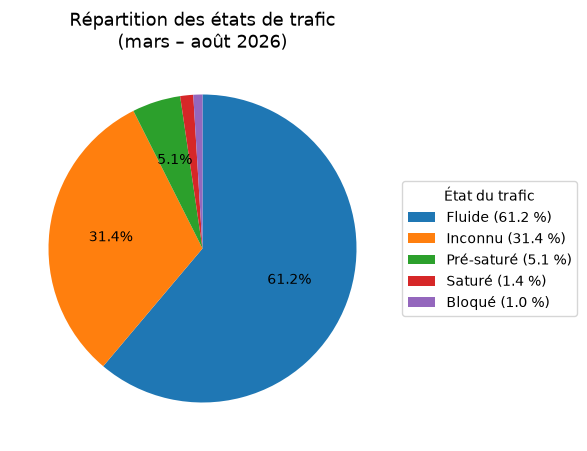

In [12]:
import matplotlib.pyplot as plt

counts = df["etat_trafic"].value_counts()
pct = counts / counts.sum() * 100

ax = counts.plot.pie(
    figsize=(7, 5),
    autopct=lambda p: f"{p:.1f}%" if p >= 5 else "", 
    labels=None,
    ylabel="",
    startangle=90,
    counterclock=False,
)
ax.set_title("Répartition des états de trafic\n(mars – août 2026)", fontsize=13)
ax.legend(
    [f"{etat} ({p:.1f} %)" for etat, p in pct.items()],
    title="État du trafic",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)
plt.show()


**Ce que montre le graphique.** Sur les données brutes, 61,2 % des mesures horaires sont classées « Fluide », contre 5,1 % « Pré-saturé », 1,4 % « Saturé » et 1,0 % « Bloqué ». Mais 31,4 % des lignes sont « Inconnu » : près d'une mesure sur trois n'a pas d'état de trafic exploitable. Cette modalité est examinée dans la partie nettoyage.

libelle
Av_Foch         620.684280
Lecourbe        396.254813
Av_Daumesnil    170.218149
Name: q, dtype: float64


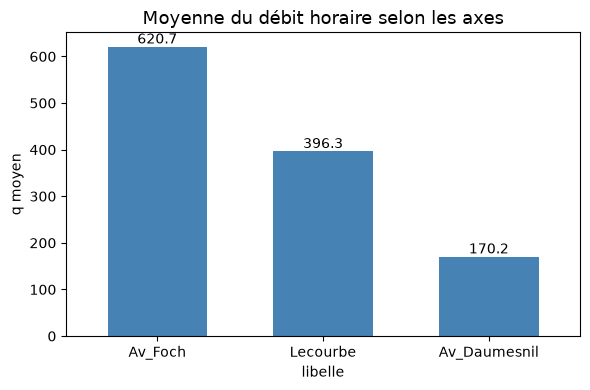

In [13]:
import matplotlib.pyplot as plt

VAR_CAT = "libelle"   # la variable à 3 modalités
VAR_NUM = "q"   # la variable quantitative

moyennes = (
    df.groupby(VAR_CAT, observed=True)[VAR_NUM]
    .mean()
    .sort_values(ascending=False)
)
print(moyennes)

ax = moyennes.plot.bar(figsize=(6, 4), color="steelblue", width=0.6)

ax.set_title(f"Moyenne du débit horaire selon les axes", fontsize=13)
ax.set_xlabel(VAR_CAT)
ax.set_ylabel(f"{VAR_NUM} moyen")
ax.bar_label(ax.containers[0], fmt="%.1f")   # affiche la valeur au-dessus de chaque barre
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Ce que montre le graphique.** L'avenue Foch a le débit horaire moyen le plus élevé (621 véhicules/heure), devant la rue Lecourbe (396) et l'avenue Daumesnil (170). Ces moyennes sont calculées sur les seules lignes où `q` est renseigné, et tous les tronçons d'un axe y pèsent autant : elles donnent un ordre de grandeur par axe, pas le trafic d'un tronçon précis.

# Jalon M2 : Types et nettoyage

### 1. Dates et fuseau horaire

`t_1h` est lue comme du texte. Elle est convertie en date, puis passée de l'UTC à l'heure de Paris : sans cela, toutes les heures seraient décalées de 1 h (hiver) ou 2 h (été), et les heures de pointe seraient mal placées.

In [14]:
df["t_1h"] = pd.to_datetime(df["t_1h"], utc=True)
print(df["t_1h"].dtype)
print(df["t_1h"].min(), "→", df["t_1h"].max())

datetime64[us, UTC]
2026-03-01 00:00:00+00:00 → 2026-08-31 23:00:00+00:00


In [15]:
df["Date_GW"] = df["t_1h"].dt.tz_convert("Europe/Paris")
print(df["Date_GW"].min(), "→", df["Date_GW"].max())

2026-03-01 01:00:00+01:00 → 2026-09-01 01:00:00+02:00


In [16]:
hors_periode = df["Date_GW"] >= pd.Timestamp("2026-09-01", tz="Europe/Paris")
print(f"{hors_periode.sum()} lignes tombent le 1er septembre en heure de Paris")
df = df[~hors_periode].copy()

92 lignes tombent le 1er septembre en heure de Paris


**Choix.** Les dates brutes vont du 1er mars 00:00 au 31 août 23:00 en UTC, soit du 1er mars 01:00 au 1er septembre 01:00 à Paris. Les 92 lignes qui tombent le 1er septembre (2 heures × 46 tronçons) sont supprimées : elles sortent de la période étudiée et formeraient une journée de 2 heures. Il manque en contrepartie l'heure 00:00 du 1er mars.

In [17]:
df["Date"] = df["Date_GW"].dt.date

In [18]:
df["Heure"] = df["Date_GW"].dt.strftime("%H:%M")

In [19]:
noms_mois = {1: "janvier", 2: "février", 3: "mars", 4: "avril", 5: "mai", 6: "juin",
             7: "juillet", 8: "août", 9: "septembre", 10: "octobre", 11: "novembre", 12: "décembre"}

df["Mois"] = df["Date_GW"].dt.month.map(noms_mois)

In [20]:
df["Mois"].value_counts()

Mois
août       34224
juillet    34224
mai        34224
juin       33120
mars       33028
avril      31832
Name: count, dtype: int64

### 2. Types

`etat_trafic` et `etat_barre` étaient déclarées en `category` à la lecture, mais elles sont revenues en texte après l'assemblage des chunks (voir `df.dtypes` plus haut). Elles n'ont que 5 et 3 modalités : elles sont reconverties en `category`. `iu_ac` reste une chaîne, c'est un identifiant et non une quantité.

In [21]:
for col in ["etat_trafic", "etat_barre"]:
    df[col] = df[col].astype("category")
df.dtypes

iu_ac                                     string
libelle                                 category
t_1h                         datetime64[us, UTC]
q                                        float64
k                                        float64
etat_trafic                             category
iu_nd_amont                               string
libelle_nd_amont                             str
iu_nd_aval                                string
libelle_nd_aval                              str
etat_barre                              category
Date_GW             datetime64[us, Europe/Paris]
Date                                      object
Heure                                        str
Mois                                         str
dtype: object

### 3. Doublons

In [22]:
print("Lignes entièrement dupliquées :", df.duplicated().sum())
print("Doublons tronçon + heure :", df.duplicated(subset=["iu_ac", "t_1h"]).sum())

Lignes entièrement dupliquées : 0
Doublons tronçon + heure : 0


In [23]:
heures_attendues = pd.date_range(df["t_1h"].min(), df["t_1h"].max(), freq="h")
print(f"{df['t_1h'].nunique()} heures présentes sur {len(heures_attendues)} attendues")
print("Lignes par tronçon :", df.groupby("iu_ac").size().unique())

4362 heures présentes sur 4414 attendues
Lignes par tronçon : [4362]


**Constat.** Aucune ligne dupliquée, et aucun tronçon n'a deux mesures pour la même heure : il n'y a rien à supprimer. Chaque tronçon a exactement 4 362 lignes, mais la période en compte 4 414 : 52 heures sont absentes pour tous les tronçons à la fois. Ces heures n'existent pas dans la source et ne sont pas recréées.

### 4. Colonnes inutiles

In [24]:
print(df.groupby("iu_ac")[["iu_nd_amont", "iu_nd_aval"]].nunique().max())

noeuds = pd.concat([
    df[["iu_nd_amont", "libelle_nd_amont"]].set_axis(["code", "nom"], axis=1),
    df[["iu_nd_aval", "libelle_nd_aval"]].set_axis(["code", "nom"], axis=1),
]).drop_duplicates()
print(f"{len(noeuds)} couples code/nom, {noeuds['code'].nunique()} codes, {noeuds['nom'].nunique()} noms")

iu_nd_amont    1
iu_nd_aval     1
dtype: int64


33 couples code/nom, 33 codes, 33 noms


In [25]:
df = df.drop(columns=["iu_nd_amont", "iu_nd_aval"])

**Choix.** Chaque tronçon a un seul carrefour amont et un seul carrefour aval, et les 33 codes de carrefour correspondent à 33 noms exactement. Les codes `iu_nd_amont` et `iu_nd_aval` répètent donc l'information des libellés : ils sont supprimés, et les noms sont gardés car ils permettent de situer un tronçon.

### 5. Valeurs manquantes

Les valeurs manquantes sont d'abord croisées avec l'état du tronçon, puis mesurées tronçon par tronçon.

In [26]:
manquant = df["q"].isna() | df["k"].isna()
print(pd.crosstab(df["etat_barre"], manquant, colnames=["q ou k manquant"]))
print()
print(pd.crosstab(df["etat_trafic"], df["k"].isna(), colnames=["k manquant"]))

q ou k manquant   False  True 
etat_barre                    
Barré               331    504
Invalide              0  33593
Ouvert           100011  66213

k manquant    False  True 
etat_trafic               
Bloqué         1921      0
Fluide       122685      0
Inconnu           0  63101
Pré-saturé    10205      0
Saturé         2740      0


In [27]:
df.groupby("etat_barre", observed=True)["q"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
etat_barre,,,,,,,,
Barré,367.0,153.6,340.1,0.0,2.0,24.0,127.0,2179.0
Invalide,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ouvert,129248.0,308.7,257.8,0.0,125.0,226.0,423.0,5518.0


In [28]:
taux_na = (
    df.assign(q_na=df["q"].isna(), k_na=df["k"].isna())
    .groupby(["libelle", "iu_ac"], observed=True)[["q_na", "k_na"]]
    .mean()
    .mul(100)
    .round(1)
)
taux_na

q_na   k_na
libelle      iu_ac              
Av_Daumesnil 4795    86.0    8.2
             4797    13.1    8.2
             4798    13.1   85.5
             4800    13.1    8.2
             4802    86.0    8.2
             4821    57.8   58.0
             4836     1.3    1.3
             4837     1.3    3.5
             4838     1.3    1.3
             4840     1.3    7.2
             4841     1.3    3.5
             4842     0.8    0.9
             4843     8.6    0.8
             4845     0.8    0.8
             4846   100.0    4.0
             5041     0.8    7.7
             5042   100.0  100.0
             5713    86.0   86.0
             5797     8.6   11.8
             5798     0.8   11.6
             5800     0.8   11.6
             5801     8.6   11.8
             905     14.8  100.0
             906     13.1   25.8
Av_Foch      4381     1.4    1.4
             4383     4.9    1.4
             4384     1.4    4.9
             4385     4.9    5.3
             4386   100.0  100.0
             4387   100.0  100.0
             4388    39.8    2.5
             4389    39.8  100.0
             4430    39.8   40.1
             4432   100.0    3.0
             4433    39.8    1.4
             4435   100.0    1.4
Lecourbe     1117   100.0    2.5
             1119   100.0    2.5
             1120   100.0    2.5
             5581     6.2  100.0
             5582     6.2  100.0
             5583     6.2  100.0
             5584     6.2    6.3
             5585     6.2    6.3
             5586     6.2  100.0
             5587   100.0  100.0

**Constats.**

- Les 33 593 lignes `Invalide` ont toutes `q` ou `k` manquant : le capteur signale lui-même que la mesure ne vaut rien.
- Les 835 lignes `Barré` correspondent à une voie fermée : le débit médian y est de 24 véhicules/heure contre 226 quand le tronçon est ouvert.
- « Inconnu » est une valeur manquante déguisée : `etat_trafic` vaut « Inconnu » exactement quand `k` est manquant (63 101 lignes dans les deux cas).
- Les manques ne sont pas répartis au hasard mais concentrés sur certains tronçons : d'après le tableau, 10 tronçons ont 100 % de `q` manquant et 10 ont 100 % de `k` manquant (à 0,1 point près), dont 4 cumulent les deux.

In [29]:
n_avant = len(df)
troncons_avant = df["iu_ac"].nunique()

df = df[df["etat_barre"] == "Ouvert"].drop(columns="etat_barre")
df["etat_trafic"] = df["etat_trafic"].cat.remove_categories("Inconnu")

print(f"{n_avant - len(df)} lignes supprimées, {len(df)} conservées ({len(df) / n_avant * 100:.1f} %)")
print(f"{troncons_avant - df['iu_ac'].nunique()} tronçons sans mesure valide disparaissent, {df['iu_ac'].nunique()} restent")

34428 lignes supprimées, 166224 conservées (82.8 %)
3 tronçons sans mesure valide disparaissent, 43 restent


In [30]:
print(df.shape)
print("Lignes sans q ni k :", (df["q"].isna() & df["k"].isna()).sum())
df.isnull().sum()

(166224, 12)
Lignes sans q ni k : 0


iu_ac                   0
libelle                 0
t_1h                    0
q                   36976
k                   29237
etat_trafic         29237
libelle_nd_amont        0
libelle_nd_aval         0
Date_GW                 0
Date                    0
Heure                   0
Mois                    0
dtype: int64

**Choix.**

- Les lignes `Invalide` et `Barré` sont supprimées (34 428 lignes, 17,2 % du total) : elles ne décrivent pas une circulation normale. `etat_barre` ne contient alors plus que « Ouvert » et la colonne est supprimée. Trois tronçons sans aucune mesure valide disparaissent, il en reste 43.
- « Inconnu » est remplacé par une vraie valeur manquante, pour ne plus être compté comme un état de trafic.
- Les valeurs manquantes restantes (36 976 pour `q`, 29 237 pour `k`) sont conservées telles quelles, sans imputation. Elles viennent surtout de tronçons où une grandeur n'est jamais mesurée : il n'existe aucune valeur voisine sur laquelle s'appuyer, et une moyenne inventerait du trafic. Les lignes sont gardées car il n'en reste aucune sans `q` ni `k` : chacune porte au moins une mesure utilisable.

# Jalon M3 : Transformation et statistiques

### 1. Variables temporelles

Quatre variables sont tirées de `Date_GW` (l'heure de Paris) : l'heure sous forme de nombre, le numéro du jour, son nom, et le type de jour (semaine ou week-end). Elles servent à comparer le trafic selon l'heure et selon le jour.

In [31]:
noms_jours = {0: "lundi", 1: "mardi", 2: "mercredi", 3: "jeudi", 4: "vendredi", 5: "samedi", 6: "dimanche"}

df["Heure_num"] = df["Date_GW"].dt.hour
df["Num_jour"] = df["Date_GW"].dt.dayofweek
df["Jour"] = df["Num_jour"].map(noms_jours)
df["Type_jour"] = df["Num_jour"].map(lambda j: "Week-end" if j >= 5 else "Semaine")

df[["Date_GW", "Heure_num", "Num_jour", "Jour", "Type_jour"]].head()

,Date_GW,Heure_num,Num_jour,Jour,Type_jour
92,2026-08-31 23:00:00+02:00,23,0,lundi,Semaine
93,2026-08-31 23:00:00+02:00,23,0,lundi,Semaine
94,2026-08-31 23:00:00+02:00,23,0,lundi,Semaine
95,2026-08-31 23:00:00+02:00,23,0,lundi,Semaine
96,2026-08-31 23:00:00+02:00,23,0,lundi,Semaine


In [32]:
print(df.groupby("Type_jour")["Date"].nunique())
print()
print(df.groupby(["Num_jour", "Jour"])["Date"].nunique())

Type_jour
Semaine     131
Week-end     53
Name: Date, dtype: int64

Num_jour  Jour    
0         lundi       27
1         mardi       26
2         mercredi    26
3         jeudi       26
4         vendredi    26
5         samedi      26
6         dimanche    27
Name: Date, dtype: int64


**Vérification.** La période compte 184 jours : 131 en semaine et 53 de week-end. Chaque jour de la semaine apparaît 26 ou 27 fois : les comparaisons entre jours reposent donc sur des effectifs équivalents.

### 2. Encodage des variables catégorielles

In [33]:
ordre_etats = ["Fluide", "Pré-saturé", "Saturé", "Bloqué"]
df["etat_trafic"] = df["etat_trafic"].cat.set_categories(ordre_etats, ordered=True)
df["etat_trafic_code"] = df["etat_trafic"].cat.codes.where(df["etat_trafic"].notna()).astype("Int8")

df["Week_end"] = (df["Num_jour"] >= 5).astype(int)

df = pd.concat([df, pd.get_dummies(df["libelle"], prefix="axe", dtype=int)], axis=1)

In [34]:
print(df[["etat_trafic", "etat_trafic_code"]].drop_duplicates().sort_values("etat_trafic_code"))
print()
print(df[["libelle", "axe_Av_Daumesnil", "axe_Av_Foch", "axe_Lecourbe"]].drop_duplicates())

    etat_trafic  etat_trafic_code
93       Fluide                 0
185  Pré-saturé                 1
236      Saturé                 2
231      Bloqué                 3
92          NaN              <NA>



          libelle  axe_Av_Daumesnil  axe_Av_Foch  axe_Lecourbe
92   Av_Daumesnil                 1            0             0
93        Av_Foch                 0            1             0
108      Lecourbe                 0            0             1


**Choix.**

- `etat_trafic` a un ordre naturel (fluide < pré-saturé < saturé < bloqué) : elle est encodée par un rang de 0 à 3 dans `etat_trafic_code`. Les états manquants restent manquants.
- `libelle` n'a aucun ordre : chaque axe devient une colonne 0/1 (`axe_...`). Un code 0, 1, 2 aurait laissé croire qu'un axe « vaut plus » qu'un autre.
- `Type_jour` n'a que deux modalités : une seule colonne `Week_end` (0 ou 1) suffit.

Les colonnes d'origine sont conservées, car elles restent plus lisibles pour les graphiques et les tableaux.

### 3. Valeurs aberrantes

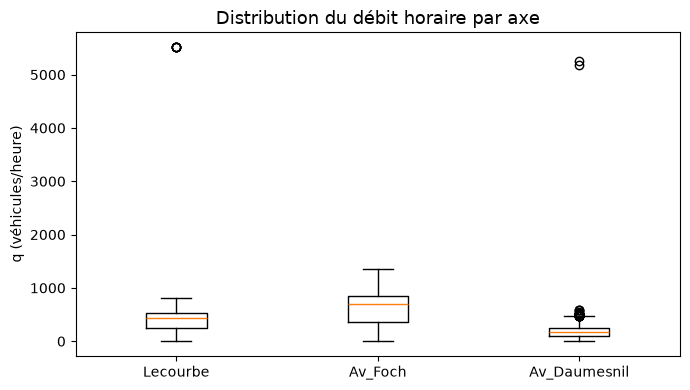

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([df.loc[df["libelle"] == axe, "q"].dropna() for axe in ROUTES])
ax.set_xticklabels(ROUTES)
ax.set_title("Distribution du débit horaire par axe", fontsize=13)
ax.set_ylabel("q (véhicules/heure)")
plt.tight_layout()
plt.show()

**Ce que montre le graphique.** Sur les trois axes, les débits habituels restent sous 1 400 véhicules/heure, l'avenue Foch étant nettement au-dessus des deux autres. Quelques points isolés dépassent 5 000 véhicules/heure sur la rue Lecourbe et l'avenue Daumesnil, soit plus de six fois le reste de la distribution : ils écrasent l'échelle et ne ressemblent à aucune autre mesure.

In [36]:
def borne_haute(s, facteur):
    q1, q3 = s.quantile([0.25, 0.75])
    return q3 + facteur * (q3 - q1)

borne_globale = borne_haute(df["q"], 1.5)
au_dessus = df[df["q"] > borne_globale]
print(f"Règle globale (1,5 × IQR) : borne à {borne_globale:.0f}, {len(au_dessus)} valeurs au-dessus")
print(au_dessus["libelle"].value_counts())
print()

par_troncon = df.groupby("iu_ac")["q"]
for facteur in (1.5, 3):
    borne = par_troncon.transform(lambda s: borne_haute(s, facteur))
    print(f"Règle par tronçon ({facteur} × IQR) : {(df['q'] > borne).sum()} valeurs au-dessus")

Règle globale (1,5 × IQR) : borne à 870, 6176 valeurs au-dessus
libelle
Av_Foch         6168
Lecourbe           6
Av_Daumesnil       2
Name: count, dtype: int64

Règle par tronçon (1.5 × IQR) : 18 valeurs au-dessus


Règle par tronçon (3 × IQR) : 8 valeurs au-dessus


In [37]:
borne = par_troncon.transform(lambda s: borne_haute(s, 3))
aberrant = df["q"] > borne

df.loc[aberrant, ["iu_ac", "libelle", "Date_GW", "q", "k", "etat_trafic"]].sort_values("Date_GW")

,iu_ac,libelle,Date_GW,q,k,etat_trafic
169156,5583,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,NaN,NaN
169157,5584,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,6.64389,Fluide
169158,5585,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,6.64389,Fluide
169159,5586,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,NaN,NaN
169175,5581,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,NaN,NaN
169176,5582,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,NaN,NaN
83070,4821,Av_Daumesnil,2026-06-17 20:00:00+02:00,5263.95,2.93944,Fluide
15926,4821,Av_Daumesnil,2026-08-17 15:00:00+02:00,5171.95,12.21945,Fluide


In [38]:
print(df[~aberrant].groupby("libelle", observed=True)["q"].max())
print()
print("k : minimum", df["k"].min(), "| maximum", df["k"].max(), "| valeurs hors de 0-100 :", ((df["k"] < 0) | (df["k"] > 100)).sum())

libelle
Av_Daumesnil     595.0
Av_Foch         1357.0
Lecourbe         808.0
Name: q, dtype: float64

k : minimum 0.0 | maximum 97.12778 | valeurs hors de 0-100 : 0


**Constats.**

- Une règle globale ne convient pas : la borne à 870 véhicules/heure signale 6 176 valeurs, dont 6 168 sur l'avenue Foch. Ce n'est pas une anomalie, c'est le trafic normal d'un axe plus chargé que les deux autres.
- La règle est donc appliquée tronçon par tronçon. Avec 1,5 × IQR, 18 valeurs ressortent, dont des débits plausibles (225 à 595 véhicules/heure). Avec 3 × IQR, il en reste 8, toutes au-dessus de 5 000.
- Ces 8 valeurs correspondent à 3 heures seulement : le 30 mars à 16 h sur six tronçons de la rue Lecourbe (5 518), et deux heures sur le tronçon 4821 de l'avenue Daumesnil (5 264 et 5 172). Sans elles, le maximum est de 808 sur Lecourbe et de 595 sur Daumesnil.
- Elles sont incohérentes avec le taux d'occupation mesuré au même moment (3 à 12 %, état « Fluide ») : un débit six fois supérieur au maximum habituel ne peut pas passer sur une voie presque vide.
- Pour `k`, toutes les valeurs sont entre 0 et 97 %, donc dans l'intervalle possible d'un pourcentage. Les valeurs élevées correspondent à de la congestion, pas à une erreur.

In [39]:
df["q"] = df["q"].mask(aberrant)
print(f"{aberrant.sum()} valeurs de q remplacées par une valeur manquante, nouveau maximum : {df['q'].max():.0f}")

8 valeurs de q remplacées par une valeur manquante, nouveau maximum : 1357


**Choix.** Les 8 débits aberrants sont remplacés par une valeur manquante, avec la règle 3 × IQR par tronçon. Les lignes sont conservées, car le taux d'occupation de ces heures reste valide. Aucune valeur de `k` n'est modifiée.

### 4. Statistiques par tronçon

Les statistiques sont calculées pour le débit `q`, puis pour le taux d'occupation `k`, sur les tronçons où la grandeur est mesurée.

In [40]:
stats_q = (
    df.dropna(subset=["q"])
    .groupby(["libelle", "iu_ac"], observed=True)["q"]
    .agg(n="count", moyenne="mean", mediane="median", ecart_type="std", minimum="min", maximum="max")
    .round(1)
)
stats_q

n  moyenne  mediane  ecart_type  minimum  maximum
libelle      iu_ac                                                      
Av_Daumesnil 4795    609    128.0    143.0        58.4     14.0    261.0
             4797   3785    161.3    180.0        73.2     12.0    342.0
             4798   3785    161.3    180.0        73.2     12.0    342.0
             4800   3785    161.3    180.0        73.2     12.0    342.0
             4802    609    128.0    143.0        58.4     14.0    261.0
             4821   1840    158.8    170.0        79.8     14.0    372.0
             4836   4295    153.7    155.0        84.3      4.0    408.0
             4837   4295    153.7    155.0        84.3      4.0    408.0
             4838   4295     86.6     88.0        43.5      3.0    226.0
             4840   4295     86.6     88.0        43.5      3.0    226.0
             4841   4295    153.7    155.0        84.3      4.0    408.0
             4842   4314    184.1    190.0        94.2      0.0    462.0
             4843   3973    222.4    235.0       105.8      0.0    595.0
             4845   4314    211.5    230.0        97.5     16.0    483.0
             5041   4314    211.5    230.0        97.5     16.0    483.0
             5713    609    128.0    143.0        58.4     14.0    261.0
             5797   3973    222.4    235.0       105.8      0.0    595.0
             5798   4314    184.1    190.0        94.2      0.0    462.0
             5800   4314    184.1    190.0        94.2      0.0    462.0
             5801   3973    222.4    235.0       105.8      0.0    595.0
             905    3704    166.6    160.0       101.4      6.0    555.0
             906    3785    161.3    180.0        73.2     12.0    342.0
Av_Foch      4381   4273    731.4    816.0       332.7      0.0   1357.0
             4383   4120    581.4    674.0       301.5      0.0   1121.0
             4384   4273    731.4    816.0       332.7      0.0   1357.0
             4385   4120    581.4    674.0       301.5      0.0   1121.0
             4388   2609    570.9    640.0       264.0      0.0   1034.0
             4389   2609    570.9    640.0       264.0      0.0   1034.0
             4430   2609    570.9    640.0       264.0      0.0   1034.0
             4433   2612    569.7    639.0       265.3      0.0   1034.0
Lecourbe     5581   4090    395.1    431.0       172.4      0.0    808.0
             5582   4090    395.1    431.0       172.4      0.0    808.0
             5583   4090    395.1    431.0       172.4      0.0    808.0
             5584   4090    395.1    431.0       172.4      0.0    808.0
             5585   4090    395.1    431.0       172.4      0.0    808.0
             5586   4090    395.1    431.0       172.4      0.0    808.0

In [41]:
stats_k = (
    df.dropna(subset=["k"])
    .groupby(["libelle", "iu_ac"], observed=True)["k"]
    .agg(n="count", moyenne="mean", mediane="median", ecart_type="std", minimum="min", maximum="max")
    .round(1)
)
stats_k

n  moyenne  mediane  ecart_type  minimum  maximum
libelle      iu_ac                                                      
Av_Daumesnil 4795   3987      3.6      3.5         2.2      0.1     13.5
             4797   3987      1.2      1.0         1.4      0.0     14.4
             4798    633      2.6      2.6         1.7      0.3     20.0
             4800   3987      1.2      1.0         1.4      0.0     14.4
             4802   3987      3.6      3.5         2.2      0.1     13.5
             4821   1832      4.2      2.4         5.2      0.2     57.1
             4836   4295      4.9      1.9         8.2      0.0     61.8
             4837   4199      1.7      1.5         1.6      0.0     36.7
             4838   4295      2.4      1.2         5.7      0.0     68.7
             4840   4038      2.3      2.1         1.8      0.2     16.8
             4841   4199      1.7      1.5         1.6      0.0     36.7
             4842   4312      3.1      3.1         2.1      0.0     30.1
             4843   4314      3.6      3.5         2.6      0.2     54.5
             4845   4314      3.7      3.9         1.8      0.3     13.3
             4846   4175      3.7      3.5         2.6      0.2     57.0
             5041   4012      3.2      3.0         2.5      0.0     47.0
             5042      1      0.0      0.0         NaN      0.0      0.0
             5713    609      2.3      2.2         2.0      0.2     30.0
             5797   3837     19.8      6.5        24.6      0.3     97.1
             5798   3846      7.4      5.6         6.5      0.3     50.4
             5800   3846      7.4      5.6         6.5      0.3     50.4
             5801   3837     19.8      6.5        24.6      0.3     97.1
             905       1      0.0      0.0         NaN      0.0      0.0
             906    3225     20.6     13.1        20.4      0.0     78.1
Av_Foch      4381   4273      2.9      3.1         1.6      0.0     20.0
             4383   4272      5.9      4.6         6.0      0.0     63.1
             4384   4119     14.6     10.2        13.6      0.0     82.8
             4385   4103      9.1      9.1         5.9      0.0     46.4
             4388   4210      6.3      4.2         7.4      0.0     58.4
             4430   2598      3.9      4.3         1.8      0.0     12.6
             4432   4186      9.4      7.0         9.8      0.0     67.3
             4433   4256     17.2     17.7         7.8      0.0     58.5
             4435   4256      9.4      9.8         4.9      0.0     42.4
Lecourbe     1117   4255      8.7      6.4         8.3      0.2     54.3
             1119   4255      8.7      6.4         8.3      0.2     54.3
             1120   4255      8.7      6.4         8.3      0.2     54.3
             5582      1      0.0      0.0         NaN      0.0      0.0
             5583      1      0.0      0.0         NaN      0.0      0.0
             5584   4089      1.9      1.6         1.5      0.2     25.6
             5585   4089      1.9      1.6         1.5      0.2     25.6
             5586      1      0.0      0.0         NaN      0.0      0.0

In [42]:
profils = (
    stats_q.reset_index()
    .groupby(["libelle", "moyenne", "mediane", "ecart_type", "maximum"], observed=True)["iu_ac"]
    .agg(nb_troncons="size", troncons=", ".join)
    .reset_index()
)
print(f"{len(stats_q)} tronçons ont un débit, pour {len(profils)} profils statistiques distincts")
profils[profils["nb_troncons"] > 1][["libelle", "moyenne", "maximum", "nb_troncons", "troncons"]]

36 tronçons ont un débit, pour 14 profils statistiques distincts


,libelle,moyenne,maximum,nb_troncons,troncons
0,Av_Daumesnil,86.6,226.0,2,"4838, 4840"
1,Av_Daumesnil,128.0,261.0,3,"4795, 4802, 5713"
2,Av_Daumesnil,153.7,408.0,3,"4836, 4837, 4841"
4,Av_Daumesnil,161.3,342.0,4,"4797, 4798, 4800, 906"
6,Av_Daumesnil,184.1,462.0,3,"4842, 5798, 5800"
7,Av_Daumesnil,211.5,483.0,2,"4845, 5041"
8,Av_Daumesnil,222.4,595.0,3,"4843, 5797, 5801"
10,Av_Foch,570.9,1034.0,3,"4388, 4389, 4430"
11,Av_Foch,581.4,1121.0,2,"4383, 4385"
12,Av_Foch,731.4,1357.0,2,"4381, 4384"


**Ce que montrent les tableaux.**

- Les tronçons de l'avenue Foch ont les débits les plus élevés : entre 570 et 731 véhicules/heure en moyenne, avec un maximum de 1 357. La rue Lecourbe est à 395 en moyenne, et les tronçons de l'avenue Daumesnil entre 87 et 222.
- L'écart-type est important partout (entre 44 % et 61 % de la moyenne selon le tronçon) : le débit varie beaucoup au cours de la journée.
- Piège des données : 36 tronçons ont un débit, mais seulement 14 profils statistiques distincts. Plusieurs tronçons voisins ont exactement la même moyenne, la même médiane et le même maximum, par exemple les six tronçons de la rue Lecourbe. Le débit semble mesuré en un point et recopié sur les tronçons voisins. Les moyennes par axe comptent donc plusieurs fois le même point de mesure.
- Le taux d'occupation, lui, diffère d'un tronçon à l'autre. Les plus occupés en moyenne sont 906, 5797 et 5801 sur l'avenue Daumesnil (environ 20 %) et 4433 sur l'avenue Foch (17 %). Quelques tronçons n'ont qu'une seule mesure de `k` (colonne `n` à 1) : leurs statistiques ne sont pas interprétables.

In [43]:
profil_horaire = (
    df.groupby(["libelle", "iu_ac", "Heure_num"], observed=True)["q"]
    .mean()
    .unstack("Heure_num")
    .dropna(how="all")
)

pointe = pd.DataFrame({
    "heure_la_plus_chargee": profil_horaire.idxmax(axis=1),
    "debit_moyen_a_cette_heure": profil_horaire.max(axis=1).round(0),
    "heure_la_plus_creuse": profil_horaire.idxmin(axis=1),
    "debit_moyen_heure_creuse": profil_horaire.min(axis=1).round(0),
})
pointe

heure_la_plus_chargee  debit_moyen_a_cette_heure  \
libelle      iu_ac                                                     
Av_Daumesnil 4795                      12                      181.0   
             4797                      10                      227.0   
             4798                      10                      227.0   
             4800                      10                      227.0   
             4802                      12                      181.0   
             4821                      11                      226.0   
             4836                      17                      243.0   
             4837                      17                      243.0   
             4838                      12                      133.0   
             4840                      12                      133.0   
             4841                      17                      243.0   
             4842                      17                      293.0   
             4843                      16                      310.0   
             4845                      12                      322.0   
             5041                      12                      322.0   
             5713                      12                      181.0   
             5797                      16                      310.0   
             5798                      17                      293.0   
             5800                      17                      293.0   
             5801                      16                      310.0   
             905                       18                      282.0   
             906                       10                      227.0   
Av_Foch      4381                      19                     1013.0   
             4383                      10                      822.0   
             4384                      19                     1013.0   
             4385                      10                      822.0   
             4388                      17                      809.0   
             4389                      17                      809.0   
             4430                      17                      809.0   
             4433                      17                      801.0   
Lecourbe     5581                      20                      558.0   
             5582                      20                      558.0   
             5583                      20                      558.0   
             5584                      20                      558.0   
             5585                      20                      558.0   
             5586                      20                      558.0   

                    heure_la_plus_creuse  debit_moyen_heure_creuse  
libelle      iu_ac                                                  
Av_Daumesnil 4795                      4                      30.0  
             4797                      4                      40.0  
             4798                      4                      40.0  
             4800                      4                      40.0  
             4802                      4                      30.0  
             4821                      4                      36.0  
             4836                      5                      27.0  
             4837                      5                      27.0  
             4838                      5                      24.0  
             4840                      5                      24.0  
             4841                      5                      27.0  
             4842                      5                      36.0  
             4843                      5                     102.0  
             4845                      4                      49.0  
             5041                      4                      49.0  
             5713                      4                      30.0  
             5797                      5 

In [44]:
debit_axe_heure = df.groupby(["libelle", "Heure_num"], observed=True)["q"].mean().round(0)
for axe in ROUTES:
    print(axe, ": 3 heures les plus chargées")
    print(debit_axe_heure[axe].nlargest(3).to_string())
    print()

Lecourbe : 3 heures les plus chargées
Heure_num
20    558.0
19    557.0
18    534.0

Av_Foch : 3 heures les plus chargées
Heure_num
17    853.0
18    852.0
19    849.0

Av_Daumesnil : 3 heures les plus chargées
Heure_num
12    240.0
17    240.0
13    236.0



**Heures les plus chargées.**

- Avenue Foch : le trafic culmine en fin de journée, entre 17 h et 19 h (environ 850 véhicules/heure en moyenne sur l'axe). Deux tronçons (4383 et 4385) ont au contraire leur maximum à 10 h.
- Rue Lecourbe : le pic est tardif, entre 18 h et 20 h (environ 558 véhicules/heure à 20 h).
- Avenue Daumesnil : le profil est plus étalé, avec deux maximums proches à 12 h et à 17 h (240 véhicules/heure). Selon le tronçon, l'heure la plus chargée va de 10 h à 18 h.
- Sur tous les tronçons, l'heure la plus creuse se situe entre 4 h et 6 h du matin.

In [45]:
print(df.shape)
df.dtypes

(166224, 21)


iu_ac                                     string
libelle                                 category
t_1h                         datetime64[us, UTC]
q                                        float64
k                                        float64
etat_trafic                             category
libelle_nd_amont                             str
libelle_nd_aval                              str
Date_GW             datetime64[us, Europe/Paris]
Date                                      object
Heure                                        str
Mois                                         str
Heure_num                                  int32
Num_jour                                   int32
Jour                                         str
Type_jour                                    str
etat_trafic_code                            Int8
Week_end                                   int64
axe_Av_Daumesnil                           int64
axe_Av_Foch                                int64
axe_Lecourbe        